In [1]:
# CELLULE 1: IMPORT DES BIBLIOTHÈQUES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


In [2]:
# CELLULE 2: CHARGEMENT DES DONNÉES
dataset = pd.read_csv("../data/processed/dataset_analytique.csv")
trc = pd.read_csv("../data/processed/sinistre_trc_enrichi.csv")

print("📊 Dataset (sinistres auto):", dataset.shape)
print("📊 TRC (sinistres chantier):", trc.shape)
print("\n📋 Colonnes dataset auto:")
print(dataset.columns.tolist())
print("\n📋 Colonnes dataset chantier:")
print(trc.columns.tolist())

📊 Dataset (sinistres auto): (410, 46)
📊 TRC (sinistres chantier): (166, 24)

📋 Colonnes dataset auto:
['id_sinistre', 'annee', 'mois', 'date_accident', 'immatriculation', 'type_engin_sinistre', 'marque_sinistre', 'age_vehicule_ans_sinistre', 'etat_vehicule', 'departement_accident', 'axe_routier', 'type_accident', 'responsabilite', 'gravite', 'tiers_implique', 'assureur_sinistre', 'montant_declare_fcfa', 'franchise_fcfa', 'montant_indemnise_fcfa', 'delai_declaration_jours', 'delai_reglement_jours', 'statut_dossier', 'conducteur_anciennete_ans', 'type_sinistre', 'type_engin_parc', 'marque_parc', 'annee_mise_en_service', 'age_vehicule_ans_parc', 'departement_affectation', 'km_parcourus_estimes', 'etat_general', 'assureur_parc', 'cout_total_fcfa', 'classe_age', 'niveau_experience', 'score_delai', 'niveau_risque', 'sinistre_grave', 'frequence_sinistre', 'score_risque', 'tranche_cout', 'annee_accident', 'mois_accident', 'jour_semaine', 'est_weekend', 'categorie_km']

📋 Colonnes dataset chant

In [3]:
# CELLULE 3: APERÇU DES DONNÉES - SINISTRES AUTO
print("="*50)
print("APERÇU SINISTRES AUTOMOBILE")
print("="*50)
print("\n🔍 5 premiers enregistrements:")
dataset.head()

APERÇU SINISTRES AUTOMOBILE

🔍 5 premiers enregistrements:


,id_sinistre,annee,mois,date_accident,immatriculation,type_engin_sinistre,marque_sinistre,age_vehicule_ans_sinistre,etat_vehicule,departement_accident,...,niveau_risque,sinistre_grave,frequence_sinistre,score_risque,tranche_cout,annee_accident,mois_accident,jour_semaine,est_weekend,categorie_km
0,AUTO-2022-001,2022,7,2022-07-17,PRT-0108-BJ,NIVELEUSE,LIEBHERR,13,MAUVAIS,OUÉMÉ,...,MOYEN,0,1,93.46,MOYEN,2022,7,Sunday,True,ELEVE
1,AUTO-2022-002,2022,3,2022-03-02,PRT-0068-BJ,BULLDOZER,LIEBHERR,10,MAUVAIS,ALIBORI,...,FAIBLE,0,1,10.46,FAIBLE,2022,3,Wednesday,False,ELEVE
2,AUTO-2022-003,2022,9,2022-09-15,PRT-0318-BJ,CAMION BENNE,MAN,9,MAUVAIS,ATLANTIQUE,...,FAIBLE,0,2,11.76,FAIBLE,2022,9,Thursday,False,ELEVE
3,AUTO-2022-004,2022,8,2022-08-27,PRT-0586-BJ,NIVELEUSE,VOLVO CE,4,BON,BORGOU,...,ELEVE,0,3,34.64,ELEVE,2022,8,Saturday,True,MOYEN
4,AUTO-2022-005,2022,9,2022-09-27,PRT-0395-BJ,CAMION MALAXEUR BÉTON,DAF,2,BON,OUÉMÉ,...,FAIBLE,0,2,62.09,FAIBLE,2022,9,Tuesday,False,MOYEN


In [4]:
# CELLULE 4: APERÇU DES DONNÉES - SINISTRES CHANTIER
print("="*50)
print("APERÇU SINISTRES CHANTIER")
print("="*50)
print("\n🔍 5 premiers enregistrements:")
trc.head()

APERÇU SINISTRES CHANTIER

🔍 5 premiers enregistrements:


,id_sinistre,annee,mois,date_declaration,code_chantier,nom_chantier,type_travaux,departement,phase_chantier,nature_sinistre,...,franchise_fcfa,montant_indemnise_fcfa,delai_declaration_jours,delai_reglement_jours,statut_dossier,responsabilite,type_sinistre,cout_total_fcfa,niveau_risque,tranche_cout
0,TRC-2022-001,2022,4,2022-04-13,CH-003,ROUTE PARAKOU-N'DALI,TERRASSEMENT,BORGOU,GROS ŒUVRE,CONDUITE EAU ENDOMMAGÉE,...,1016000,0.0,8,0.0,EN EXPERTISE,PORTEO ENTIÈRE,TRC,1016000.0,MOYEN,MOYEN
1,TRC-2022-002,2022,10,2022-10-19,CH-029,ROUTE COVÈ-ZAGNANADO,TERRASSEMENT,ZOU,GROS ŒUVRE,DOMMAGES PROPRIÉTÉ RIVERAINE,...,1208000,0.0,21,0.0,EN COURS,PORTEO ENTIÈRE,TRC,1208000.0,MOYEN,MOYEN
2,TRC-2022-003,2022,8,2022-08-07,CH-007,BITUMAGE NATITINGOU-TANGUIÉTA,BITUMAGE,ATACORA,TERRASSEMENT,DOMMAGES PROPRIÉTÉ RIVERAINE,...,984000,2571000.0,20,156.0,LITIGIEUX,PORTEO PARTIELLE,TRC,3555000.0,MOYEN,MOYEN
3,TRC-2022-004,2022,1,2022-01-17,CH-013,PONT SUR OUÉMÉ À ADJOHOUN,OUVRAGE D'ART,OUÉMÉ,FINITION,EFFONDREMENT DE TALUS,...,375000,16101000.0,11,45.0,LITIGIEUX,PORTEO PARTIELLE,TRC,16476000.0,ELEVE,ELEVE
4,TRC-2022-005,2022,10,2022-10-08,CH-014,VOIRIE PARAKOU ZONE INDUSTRIELLE,VRD,BORGOU,TERRASSEMENT,DOMMAGES PROPRIÉTÉ RIVERAINE,...,682000,1562000.0,6,184.0,RÉGLÉ,PORTEO ENTIÈRE,TRC,2244000.0,MOYEN,MOYEN


In [5]:
# CELLULE 5: STATISTIQUES GLOBALES
print("="*50)
print("STATISTIQUES GLOBALES")
print("="*50)

# Création d'un résumé comparatif
resume = {
    'Indicateur': [
                'Nombre total de sinistres',
                'Coût total (FCFA)',
                'Coût moyen par sinistre (FCFA)',
                'Médiane des coûts (FCFA)',
                'Coût maximum (FCFA)',
                'Délai moyen de déclaration (jours)',
                'Délai moyen de règlement (jours)',
                'Taux de sinistres graves (%)'
    ],
    'Sinistres Auto': [
        len(dataset),
        f"{dataset['cout_total_fcfa'].sum():,.0f}",
        f"{dataset['cout_total_fcfa'].mean():,.0f}",
        f"{dataset['cout_total_fcfa'].median():,.0f}",
        f"{dataset['cout_total_fcfa'].max():,.0f}",
        f"{dataset['delai_declaration_jours'].mean():.1f}",
        f"{dataset['delai_reglement_jours'].mean():.1f}",
        f"{(dataset['sinistre_grave'].mean()*100 if 'sinistre_grave' in dataset.columns else 'N/A'):.1f}"
    ],
    'Sinistres Chantier': [
        len(trc),
        f"{trc['cout_total_fcfa'].sum():,.0f}",
        f"{trc['cout_total_fcfa'].mean():,.0f}",
        f"{trc['cout_total_fcfa'].median():,.0f}",
        f"{trc['cout_total_fcfa'].max():,.0f}",
        f"{trc['delai_declaration_jours'].mean():.1f}",
        f"{trc['delai_reglement_jours'].mean():.1f}",
        "N/A (à créer)"
    ]
}

pd.DataFrame(resume)

STATISTIQUES GLOBALES


,Indicateur,Sinistres Auto,Sinistres Chantier
0,Nombre total de sinistres,410,166
1,Coût total (FCFA),"717,395,000","417,961,000"
2,Coût moyen par sinistre (FCFA),"1,749,744","2,517,837"
3,Médiane des coûts (FCFA),"386,000","1,302,500"
4,Coût maximum (FCFA),"27,071,000","16,742,000"
5,Délai moyen de déclaration (jours),5.4,10.6
6,Délai moyen de règlement (jours),48.3,92.6
7,Taux de sinistres graves (%),0.0,N/A (à créer)


DISTRIBUTION DES COÛTS


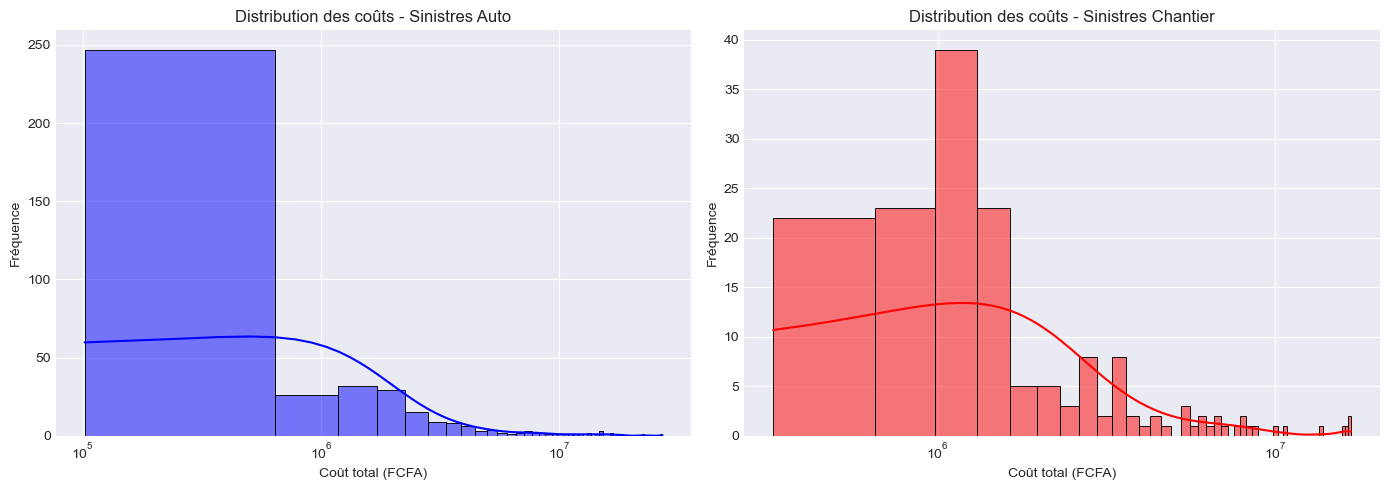


📊 Statistiques détaillées - Sinistres Auto:
count    4.100000e+02
mean     1.749744e+06
std      3.357204e+06
min      1.020000e+05
25%      2.672500e+05
50%      3.860000e+05
75%      1.757500e+06
max      2.707100e+07
Name: cout_total_fcfa, dtype: float64

📊 Statistiques détaillées - Sinistres Chantier:
count    1.660000e+02
mean     2.517837e+06
std      3.110480e+06
min      3.260000e+05
25%      9.105000e+05
50%      1.302500e+06
75%      2.722250e+06
max      1.674200e+07
Name: cout_total_fcfa, dtype: float64


In [6]:
# CELLULE 7: DISTRIBUTION DES COÛTS
print("="*50)
print("DISTRIBUTION DES COÛTS")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des coûts auto
sns.histplot(dataset['cout_total_fcfa'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution des coûts - Sinistres Auto')
axes[0].set_xlabel('Coût total (FCFA)')
axes[0].set_ylabel('Fréquence')
axes[0].set_xscale('log')

# Distribution des coûts chantier
sns.histplot(trc['cout_total_fcfa'], bins=50, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution des coûts - Sinistres Chantier')
axes[1].set_xlabel('Coût total (FCFA)')
axes[1].set_ylabel('Fréquence')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("\n📊 Statistiques détaillées - Sinistres Auto:")
print(dataset['cout_total_fcfa'].describe())
print("\n📊 Statistiques détaillées - Sinistres Chantier:")
print(trc['cout_total_fcfa'].describe())

ÉVOLUTION TEMPORELLE


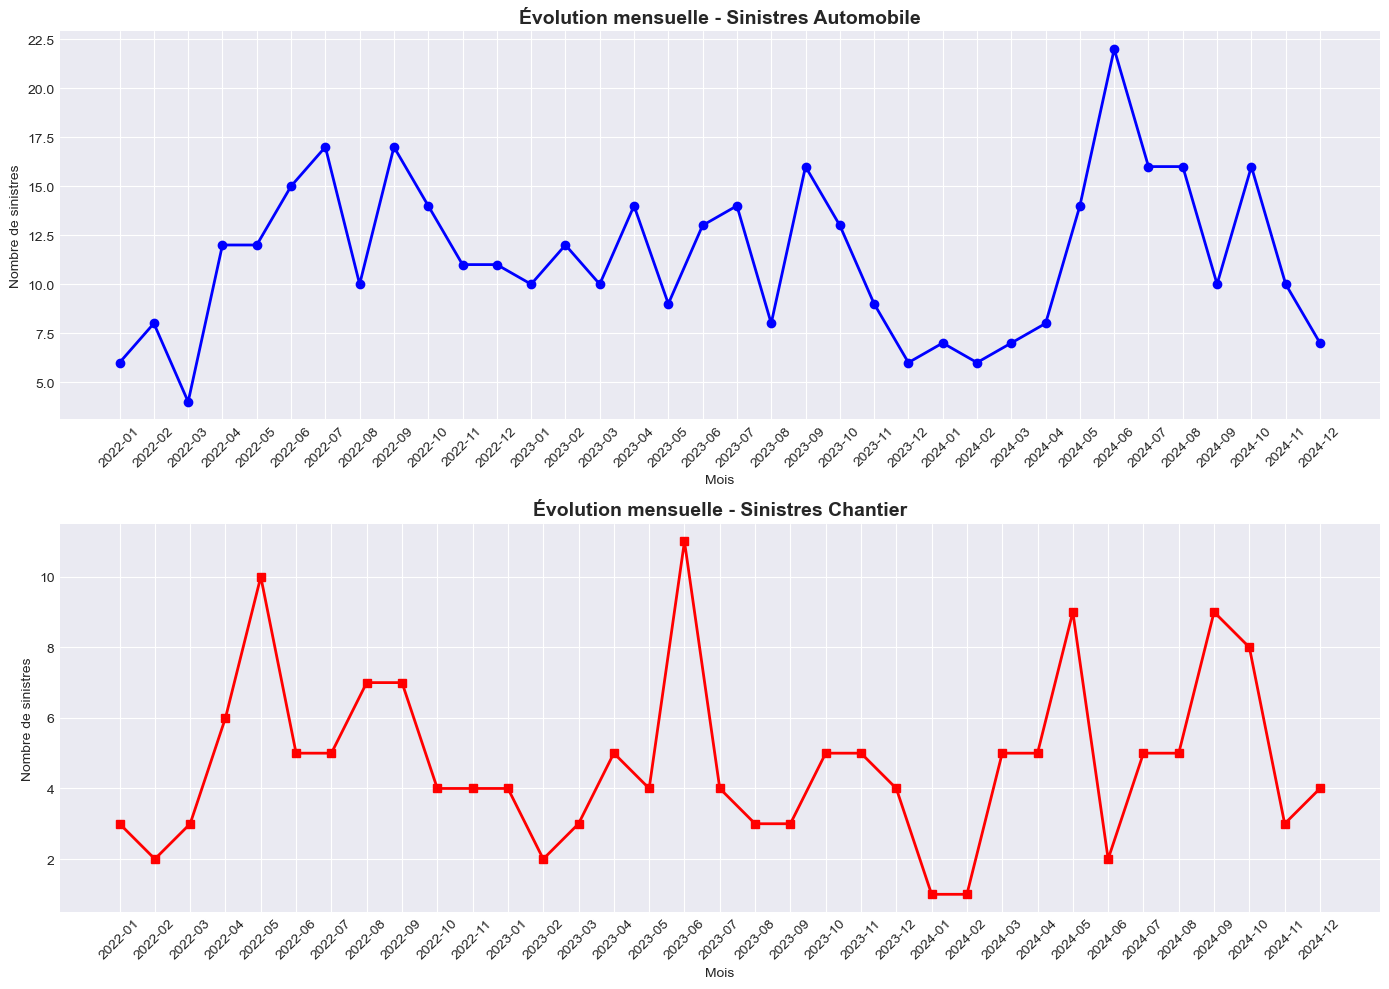

In [21]:
# CELLULE 8: ÉVOLUTION TEMPORELLE DES SINISTRES
print("="*50)
print("ÉVOLUTION TEMPORELLE")
print("="*50)

# Création d'une colonne date complète
dataset['date_sinistre'] = pd.to_datetime(dataset['date_accident'])
trc['date_sinistre'] = pd.to_datetime(trc['date_declaration'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Évolution mensuelle - Sinistres Auto
auto_mensuel = dataset.groupby(dataset['date_sinistre'].dt.to_period('M')).size()
axes[0].plot(auto_mensuel.index.astype(str), auto_mensuel.values, marker='o', color='blue', linewidth=2)
axes[0].set_title('Évolution mensuelle - Sinistres Automobile', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Nombre de sinistres')
axes[0].tick_params(axis='x', rotation=45)

# Évolution mensuelle - Sinistres Chantier
chantier_mensuel = trc.groupby(trc['date_sinistre'].dt.to_period('M')).size()
axes[1].plot(chantier_mensuel.index.astype(str), chantier_mensuel.values, marker='s', color='red', linewidth=2)
axes[1].set_title('Évolution mensuelle - Sinistres Chantier', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de sinistres')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ANALYSE GÉOGRAPHIQUE


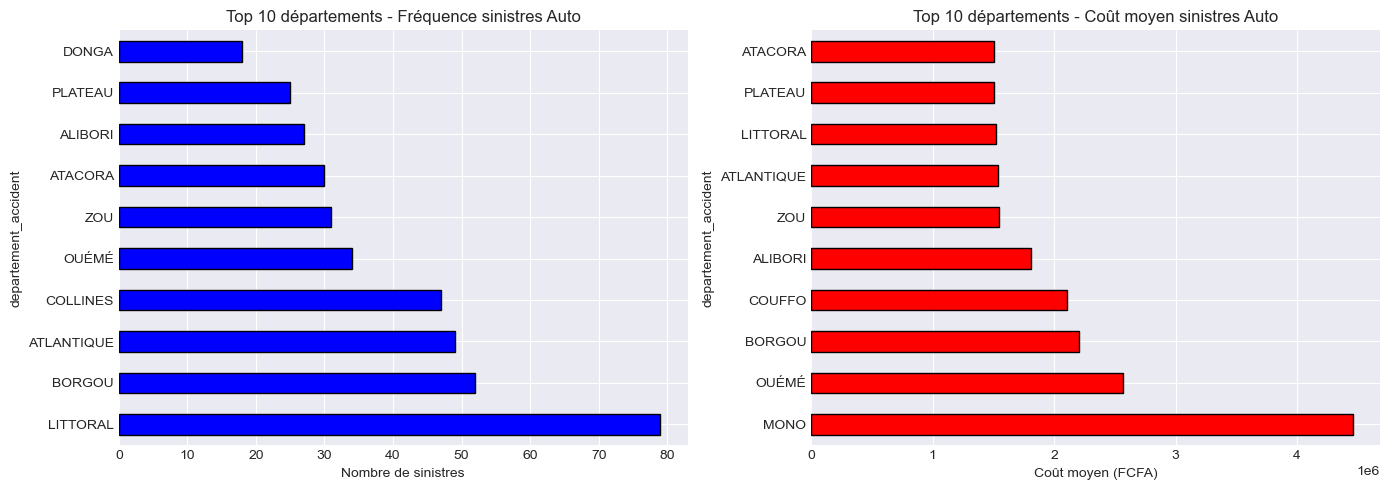


📊 Département le plus à risque (fréquence): LITTORAL (79 sinistres)
📊 Département le plus coûteux (moyenne): MONO (4,459,222 FCFA)


In [7]:
# CELLULE 10: ANALYSE GÉOGRAPHIQUE
print("="*50)
print("ANALYSE GÉOGRAPHIQUE")
print("="*50)

if 'departement_accident' in dataset.columns:
    # Top 10 départements avec le plus de sinistres auto
    top_dept_auto = dataset['departement_accident'].value_counts().head(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    top_dept_auto.plot(kind='barh', ax=axes[0], color='blue', edgecolor='black')
    axes[0].set_title('Top 10 départements - Fréquence sinistres Auto')
    axes[0].set_xlabel('Nombre de sinistres')
    
    # Coût moyen par département
    cout_par_dept = dataset.groupby('departement_accident')['cout_total_fcfa'].mean().sort_values(ascending=False).head(10)
    cout_par_dept.plot(kind='barh', ax=axes[1], color='red', edgecolor='black')
    axes[1].set_title('Top 10 départements - Coût moyen sinistres Auto')
    axes[1].set_xlabel('Coût moyen (FCFA)')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Département le plus à risque (fréquence):", top_dept_auto.index[0], f"({top_dept_auto.values[0]} sinistres)")
    print("📊 Département le plus coûteux (moyenne):", cout_par_dept.index[0], f"({cout_par_dept.values[0]:,.0f} FCFA)")

ANALYSE DE LA RESPONSABILITÉ


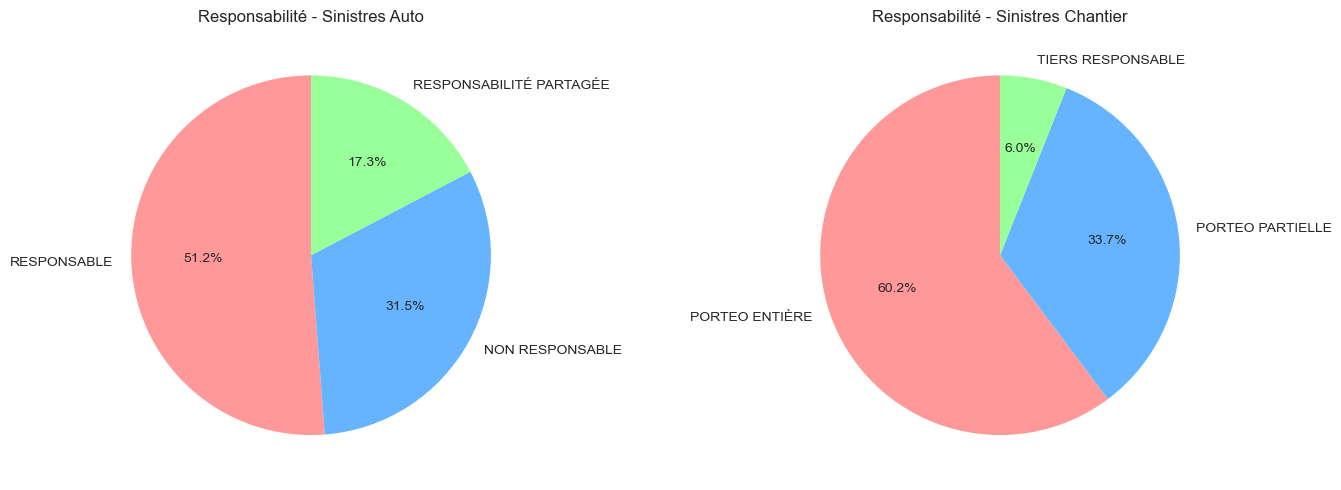


📊 Coût moyen selon responsabilité (Auto):
                                 mean    median  count
responsabilite                                        
NON RESPONSABLE          1.880357e+06  386000.0    129
RESPONSABILITÉ PARTAGÉE  1.846141e+06  391000.0     71
RESPONSABLE              1.636919e+06  385500.0    210


In [8]:
# CELLULE 11: ANALYSE DES RESPONSABILITÉS
print("="*50)
print("ANALYSE DE LA RESPONSABILITÉ")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pour sinistres auto
if 'responsabilite' in dataset.columns:
    resp_auto = dataset['responsabilite'].value_counts()
    axes[0].pie(resp_auto.values, labels=resp_auto.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
    axes[0].set_title('Responsabilité - Sinistres Auto')

# Pour sinistres chantier
if 'responsabilite' in trc.columns:
    resp_chantier = trc['responsabilite'].value_counts()
    axes[1].pie(resp_chantier.values, labels=resp_chantier.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
    axes[1].set_title('Responsabilité - Sinistres Chantier')

plt.tight_layout()
plt.show()

# Analyse croisée responsabilité vs coût
if 'responsabilite' in dataset.columns:
    print("\n📊 Coût moyen selon responsabilité (Auto):")
    print(dataset.groupby('responsabilite')['cout_total_fcfa'].agg(['mean', 'median', 'count']))